# Data Visualization - Part 2: Customizing Plots
```
Course: ENV 700 - Environmental Data Exploration
Authors: John Fay & Luana Lima
```

## Overview
### Seaborn vs Matplotlib
- Matplotlib is Python's foundational plotting library.
- Seaborn builds on Matplotlib to provide a simpler, more consistent interface for statistical graphics.
- In this lesson you'll learn how to customize Seaborn plots while mostly staying within the Seaborn interface.

### There are two levels of customization in Seaborn:
- **Theme-level customization** changes the default appearance of every plot you create.
- **Plot-level customization** changes the appearance of an individual plot after it has been created.

### Overall goals:
- Learn how to make plots more communicative and aesthetic by controlling various plot features
- Develop a mental model how to do this with Seaborn

---
## Learning objectives

By the end of this lesson, you should be able to:
* Apply Seaborn **themes** to create clear, professional-looking visualizations.
* Customize the appearance of plots using `sns.set_theme()` and the `rc` parameter.
* Modify plot titles, axis labels, axis limits, and tick labels using methods of the **FacetGrid object**.
* Customize **legends** to improve the clarity and readability of a figure.
* Select appropriate **color palettes** for categorical, sequential, and diverging data.
* Create and customize **faceted plots** to compare patterns across groups.
* Add **reference lines** and **annotations** to highlight important values or events.


---
## Setup

#### Packages/Paths/Data Import
* We will again work with the processed Peter & Paul Lakes and EPA air quality datasets

In [ ]:
# Packages
from pathlib import Path
import pandas as pd
import seaborn as sns
import datetime
import calendar

# Paths
root_fldr = Path.cwd().parent
raw_fldr = root_fldr / "data" / "raw"
processed_fldr = root_fldr / "data" / "processed"

# Data import: Peter & Paul Lakes 
PeterPaul_chem_nutrients = pd.read_csv(
    processed_fldr/'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv',
    parse_dates=['sampledate']
)

#Add month categories

# Data import: EPA AQS data
EPAair = pd.read_csv(
    processed_fldr/'EPAair_O3_PM25_NC2425_Processed.csv',
    parse_dates=['Date']
)

#Add month categories
PeterPaul_chem_nutrients['Month_name'] = pd.Categorical(
    values =PeterPaul_chem_nutrients['sampledate'].dt.month_name(),
    categories =calendar.month_name[1:]
)
EPAair['Month_name'] = pd.Categorical(
    values =EPAair['Date'].dt.month_name(),
    categories =calendar.month_name[1:]
)



,Date,Local Site Name,County,Site Latitude,Site Longitude,Year,Month,Ozone,PM2.5,Month_name
0,2024-01-01,Bryson City,Swain,35.434767,-83.442133,2024,1,NaN,43.0,January
1,2024-01-01,Castle Hayne,New Hanover,34.364167,-77.838611,2024,1,NaN,44.5,January
2,2024-01-01,Clemmons Middle,Forsyth,36.026612,-80.341962,2024,1,NaN,47.5,January
3,2024-01-01,Durham Armory,Durham,36.032955,-78.904037,2024,1,NaN,61.0,January
4,2024-01-01,Frying Pan Mountain,Haywood,35.379167,-82.792500,2024,1,NaN,14.0,January


---
## 📊[Theme-level customization](https://seaborn.pydata.org/tutorial/aesthetics.html#seaborn-figure-styles)
* Themes control the overall appearance of a plot (background, gridlines, fonts, and scaling). 
* These settings are independent of the data being visualized and apply to all plots created after setting them. 
* In Seaborn, what we call a “theme” is actually a combination of ***style*** and ***context***.

### [Theme *style*](https://seaborn.pydata.org/tutorial/aesthetics.html#seaborn-figure-styles)
* A theme's **style** controls the structural appearance of the plot (background, gridlines, spines, ticks)
* Seaborn has five preset options: `darkgrid`, `whitegrid`, `dark`, `white`, and `ticks`. 

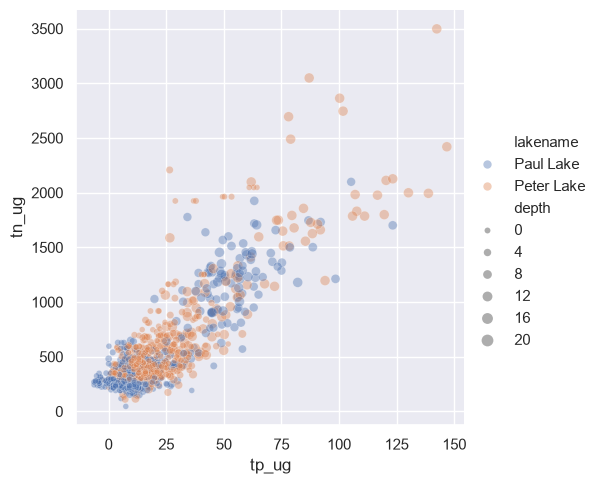

In [ ]:
#Set the default theme to use
sns.set_theme(style='darkgrid')

#See it in action
sns.relplot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug',
    y='tn_ug',
    hue='lakename',
    size='depth',
    alpha=0.4
);


##### 👉 You try it:
* Try the plot with different themes.
* Which do you feel shows the data best? Why?
* List two other changes to the plot that would make it better?

>ANSWER: I do prefer either the darkgrid or lightgrid themes, because I think they make it easiest to see the measurements with a quick glance, but I would change the axis titles and the key and make the dots slightly less opaque to increase readibility.

### [Theme *context*](https://seaborn.pydata.org/generated/seaborn.plotting_context.html#seaborn.plotting_context)
* A theme's **context** controls the overall scaling of plot elements for different uses
* The context adjusts default font sizes, line widths, and marker sizes for specific media
* Context options include: `notebook` (default), `paper`, `talk`, and `poster`.

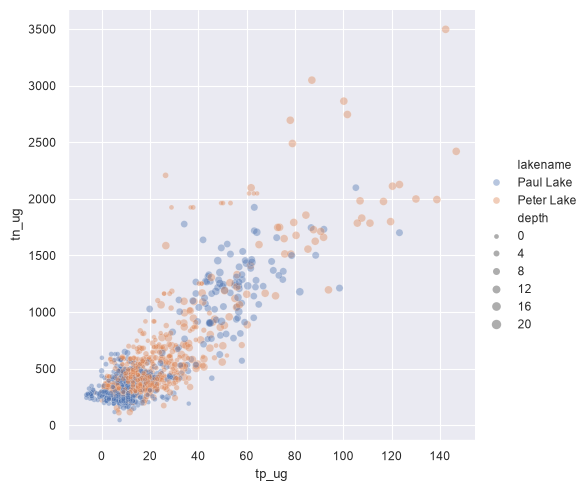

In [13]:
#Set the theme style and context
sns.set_theme(
    style='darkgrid',
    context='paper'
    )

#See it in action
sns.relplot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug',
    y='tn_ug',
    hue='lakename',
    size='depth',
    alpha=0.4
);

##### 👉 You try it:
* Change the theme context and re-run the code.

### [Additional Theme Customizations](https://seaborn.pydata.org/generated/seaborn.axes_style.html)
* `set_theme()` has an `rc` ("runtime configuration") parameter that allows element-specific customization. 
* These customizations take the form of a dictionary of `element`:`setting` pairs. 
   - Use [`sns_axes_style()`](https://seaborn.pydata.org/generated/seaborn.axes_style.html) to list all the attributes you can change. 
* The table below offers a concise guide to the most meaningful `rc` parameters:
   | If you want to change...           | `rc` parameter(s)                                                                      | Typical values              |
   | ---------------------------------- | -------------------------------------------------------------------------------------- | --------------------------- |
   | Figure background                  | `figure.facecolor`                                                                     | `"white"`, `"#F8F8F8"`      |
   | Plot background                    | `axes.facecolor`                                                                       | `"white"`, `"#EAEAF2"`      |
   | Axis labels and other text         | `axes.labelcolor`<br>`text.color`                                                      | `"black"`, `"0.3"`          |
   | Font                               | `font.family`<br>`font.sans-serif`                                                     | `"sans-serif"`, `["Arial"]` |
   | Show or hide the grid              | `axes.grid`                                                                            | `True`, `False`             |
   | Grid appearance                    | `grid.color`<br>`grid.linestyle`                                                       | `"lightgray"`, `"--"`       |
   | Draw the grid behind the data      | `axes.axisbelow`                                                                       | `True`, `False`             |
   | Show or hide plot borders (spines) | `axes.spines.left`<br>`axes.spines.bottom`<br>`axes.spines.right`<br>`axes.spines.top` | `True`, `False`             |
   | Tick color                         | `xtick.color`<br>`ytick.color`                                                         | `"black"`, `"gray"`         |
   | Tick direction                     | `xtick.direction`<br>`ytick.direction`                                                 | `"out"`, `"in"`             |
   | Which sides display ticks          | `xtick.top`<br>`xtick.bottom`<br>`ytick.left`<br>`ytick.right`                         | `True`, `False`             |
 🔥*You don't need to memorize these parameters. The goal is simply to know that most theme elements can be customized using `rc=`.*🔥


In [14]:
#List all the style elements you can change in the 'darkgrid' theme
sns.axes_style(style='darkgrid')

{'figure.facecolor': 'white',
 'axes.labelcolor': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'axes.axisbelow': True,
 'grid.linestyle': '-',
 'text.color': '.15',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'lines.solid_capstyle': 'round',
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'xtick.top': False,
 'ytick.right': False,
 'axes.grid': True,
 'axes.facecolor': '#EAEAF2',
 'axes.edgecolor': 'white',
 'grid.color': 'white',
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True,
 'xtick.bottom': False,
 'ytick.left': False}

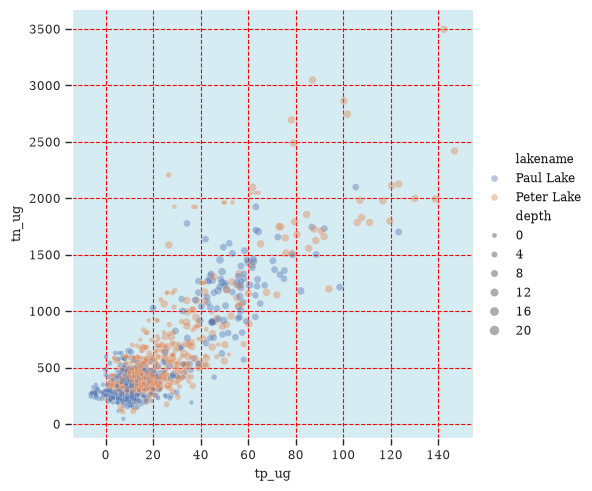

In [15]:
#Set the theme style & context, then add additional modifications using rc
sns.set_theme(
    style='darkgrid',
    context='paper',
    rc={
        'axes.facecolor': '#d6ecf3',
        'grid.color': 'red',
        'grid.linestyle': '--',
        'text.color': '#111111',
        'xtick.bottom':True,
        'ytick.left':True,
        'font.family':'serif'
    }
    )

#View it in action
sns.relplot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug',
    y='tn_ug',
    hue='lakename',
    size='depth',
    alpha=0.4
);

#### 👉 You try it:
* Alter some additional `rc` parameters and view the results. 

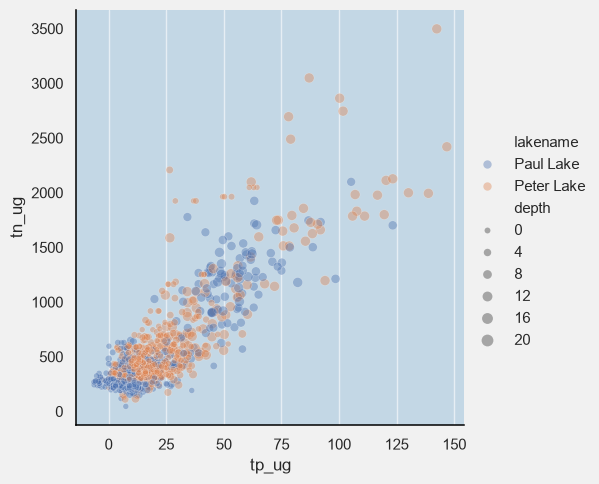

In [21]:
#Set the theme style and context
sns.set_theme(
    style='whitegrid',
    context='notebook',
    rc={
        "figure.facecolor": "#F1F1F1",
        "axes.facecolor": "#C3D7E5",
        "axes.spines.top": True,
        "axes.spines.right": True,
        "axes.spines.bottom": True,
        "axes.grid.axis": "x",
        "grid.color": "#FFFFFF",
        "grid.alpha": 0.6,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.1,
 })

#View it in action
sns.relplot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug',
    y='tn_ug',
    hue='lakename',
    size='depth',
    alpha=0.4
);

### Summary: Themes
Seaborn’s theme setting controls the overall visual appearance of a plot—such as backgrounds, gridlines, and fonts—and are independent of the data being displayed. 

In contrast, elements tied to the data itself—such as legend entries, axis scales, and axis labels—are specified through plotting functions and their parameters.

Before continuing, let's reset all our changes to the current theme. 

In [22]:
#Reset the theme
sns.set_theme(style='darkgrid')

---
## 📊Plot-level customization

Theme-level settings establish the default appearance of all plots created afterward. ***Plot-level*** settings customize an individual figure—for example, its title, axis labels, limits, legends, and tick labels—without changing future plots.

### The [`FacetGrid`](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html#seaborn.FacetGrid) object

* To customize the appearance of a specific plot, we first access the plot as an object.
* Figure-level Seaborn functions (such as `relplot()` and `catplot()`) return a **FacetGrid** object, which is commonly assigned to a variable named `g`.
* The `FacetGrid` object provides properties and methods that allow us to customize the plot after it has been created.
* Below we describe these compontent and examine how they can be controlled in our code.

### The `FacetGrid.set()` method
* The FacetGrid's `set()` method allows us to customize many aspects of our plot. 
* The table below lists the many of the properties we can set:
    | Parameter     | Purpose              | Example                              |
    | ------------- | -------------------- | ------------------------------------ |
    | `title`       | Set subplot title(s) | `title="My Plot"`                    |
    | `xlabel`      | X-axis label         | `xlabel="Temperature (°C)"`          |
    | `ylabel`      | Y-axis label         | `ylabel="Chlorophyll (µg/L)"`        |
    | `xlim`        | X-axis limits        | `xlim=(0, 100)`                      |
    | `ylim`        | Y-axis limits        | `ylim=(0, 50)`                       |
    | `xticks`      | Tick locations       | `xticks=[0, 25, 50, 75, 100]`        |
    | `yticks`      | Tick locations       | `yticks=[0, 10, 20, 30]`             |
    | `xticklabels` | Tick labels          | `xticklabels=["Jan", "Feb", "Mar"]`  |
    | `yticklabels` | Tick labels          | `yticklabels=["Low", "Med", "High"]` |
    | `xscale`      | Axis scale           | `xscale="log"`                       |
    | `yscale`      | Axis scale           | `yscale="log"`                       |
    | `facecolor`   | Background color     | `facecolor="whitesmoke"`             |

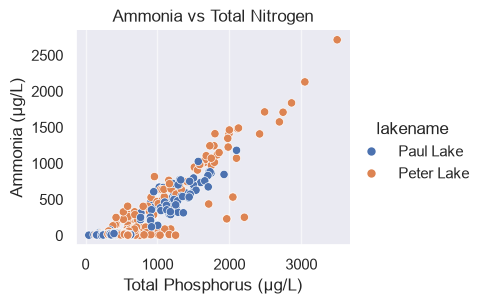

In [23]:
#Create a plot, saving the output as a variable 'g'
g = sns.relplot(
    data=PeterPaul_chem_nutrients,
    x="tn_ug",
    y="nh34",
    hue="lakename",
    height=3,
    aspect=1.3,
)

#Set properties of the plot object
g.set(
    title  = 'Ammonia vs Total Nitrogen',
    xlabel = 'Total Phosphorus (\N{Greek small letter mu}g/L)',
    ylabel = 'Ammonia (\u03BCg/L)'
);

>🔥 To include special symbols like Greek letters you can either use its *unicode value* or its *name code* using the techniques shown above. Both can be found [here](https://unicodelookup.com/).🔥

### Specialized `set_...()` methods. 
* The `set()` method is a convenient way to change the most common properties of a plot, such as its title, axis labels, and axis limits. 
* Some plot elements, however, require their own methods. For example, changing the appearance of tick labels—such as rotating dates along the x-axis—is handled by `set_xticklabels()` and `set_yticklabels()`.

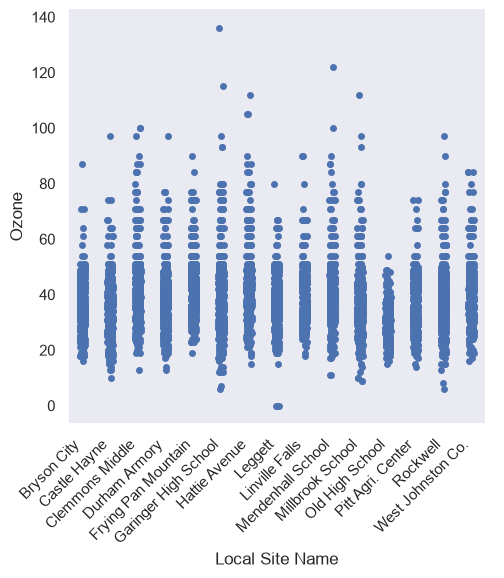

In [24]:
g = sns.catplot(
    data=EPAair,
    x='Local Site Name',
    y='Ozone'
)
#Use set_xticklabels to rotate x tick labels 45° and align them horizontally to the right
g.set_xticklabels(rotation=45,ha='right');

* For detailed help on the parameters for these methods, we need to dig into the *MatPlotLib* package, on which Seaborn is based. 
    - [Help on `set_xticklabels()` "kwargs"](https://matplotlib.org/stable/api/text_api.html#matplotlib.text.Text)

#### 👉 You try it:
* Create a scatter from the Peter/Paul Lakes data showing the dissolved oxygen as a function of temperature for surface records, with points colored by lake name. 
* You'll notice that most of the temperature data falls between 10 and 30°C and the DO data has outliers above 15 ppm. Use the `xlim` and `ylim` properties to constrain data to data within these values. 
* Set the x-axis and y-axis labels to be something more meaningful: `xlabel=...`, `ylabel=...` 
* Give the plot a title: `title=...`

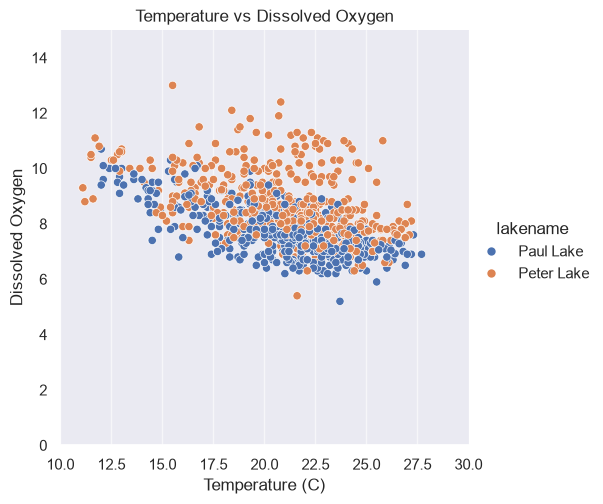

In [27]:
#Create the initial plot
g=sns.relplot(
    data=PeterPaul_chem_nutrients.query('depth == 0'),
    x='temperature_C',
    y='dissolvedOxygen',
    hue='lakename'
)

#Change some axis parameters
g.set(
    xlim=(10,30),
    ylim=(0,15),
    xlabel='Temperature (C)',
    ylabel='Dissolved Oxygen',
    title='Temperature vs Dissolved Oxygen'
)


### Customizing Legends with [`sns.move_legend()`](https://seaborn.pydata.org/generated/seaborn.move_legend.html#seaborn-move-legend)
* Legends are separate objects associated with the figure rather than axis properties, so they cannot be modified using `.set()`.
* The easiest way to work with legends is via `sns.move_legend()` which does more than just move the legend. 
    - We provide the Facet Grid object (`g`) as an argument to this function. 
* Help on the properties of the legend object is best by view its [matplotlib source](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html#matplotlib.axes.Axes.legend).

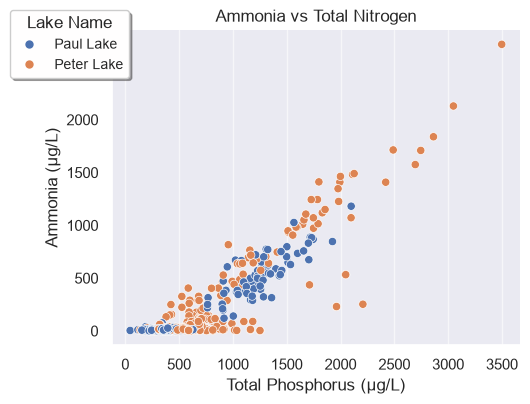

In [34]:
#Create a plot, saving the output as a variable 'g'
g = sns.relplot(
    data=PeterPaul_chem_nutrients,
    x="tn_ug",
    y="nh34",
    hue="lakename",
    height=4,
    aspect=1.3,
).set(
    title  = 'Ammonia vs Total Nitrogen',
    xlabel = 'Total Phosphorus (\N{Greek small letter mu}g/L)',
    ylabel = 'Ammonia (\u03BCg/L)',
);

#Customize the legend
sns.move_legend(
    g, 
    loc='right', #Switch to "upper left"
    title='Lake Name',
    facecolor="#FFFEFE",
    shadow=True,
    bbox_to_anchor=(0.2,0.92),
    title_fontsize=12,
    fontsize=10,
    ncols=1,
    frameon=True
)

---
## 📊Visual Encodings

Once a plot has been labeled and formatted, the next step is deciding how the data itself will be represented visually. **Visual encodings** map variables in your dataset to graphical properties such as ***color***, ***marker shape***/***line style***, and ***size***. Choosing appropriate encodings makes patterns and group differences easier to interpret. Seaborn provides simple, consistent options for applying these encodings across all of its figure-level plotting functions.

### Color

* Seaborn's [tutorial on Color Palettes](https://seaborn.pydata.org/tutorial/color_palettes.html) offers an excellent overview on how colors should be used in visualization. 
* A rule of thumb for selecting palettes is as follows:
    * Use **qualitative** palettes for categories.
    * Use **sequential** palettes for increasing numeric values.
    * Use **diverging** palettes when values are centered around an important midpoint.
    * Prefer palettes that remain readable for viewers with color-vision deficiencies.
    * Keep the number of colors to the minimum needed to answer the question.
* Applying a color palette is simply a matter of setting the `palette` property in your plot function. 
* Some example palettes are provided here:
    | Data type                         | Palette type | Examples                      |
    | --------------------------------- | ------------ | ----------------------------- |
    | Categories                        | Qualitative  | `deep`, `Set2`, `colorblind`  |
    | Ordered numeric values            | Sequential   | `viridis`, `mako`, `rocket`   | 
    | Values centered around a midpoint | Diverging    | `coolwarm`, `vlag`, `icefire` |
* Adding "`_r`" to a non-categorical palette name will often reverse it. 
* A complete gallery is available in the [Seaborn documentation](https://seaborn.pydata.org/tutorial/color_palettes.html).


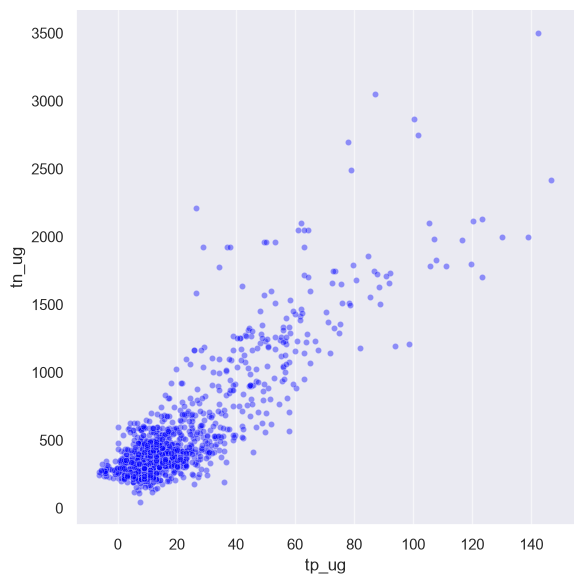

In [35]:
#Set the theme
sns.set_theme(style='darkgrid')

#Plot
g=sns.relplot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug',
    y='tn_ug',
    color='blue',        #<--- set all markers to a single color
    #hue='depth',        #<--- base colors on values in a column
    #palette='mako_r',   #<--- control what those colors are
    height=6,
    alpha=0.4,
    s=20                
)

#Show the legend if a column is used for hue
#g.legend.set_title("Depth")

### Marker shape
* Different marker shapes make plots easier to interpret when printed in grayscale or viewed by people with color vision deficiencies. 
* In Seaborn, marker shapes are typically assigned using the `style=` parameter, with optional control over the specific symbols through `markers=`.
* A [link](https://seaborn.pydata.org/tutorial/properties.html#marker) to all the markers used in Seaborn.

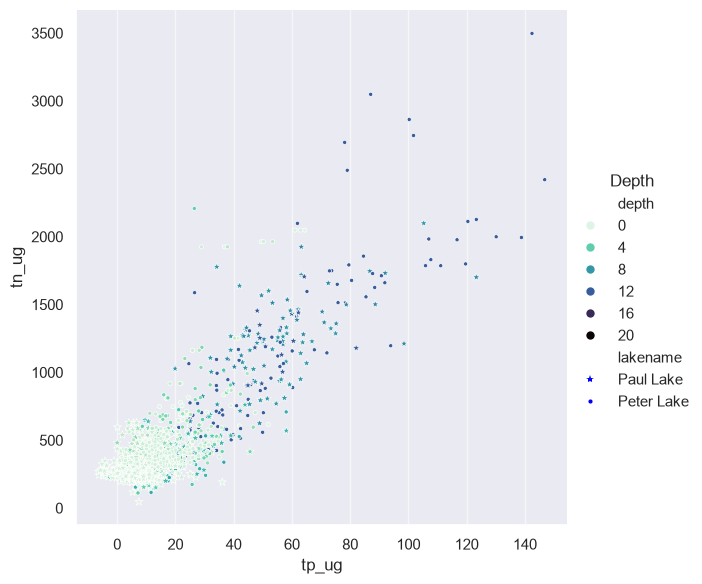

In [40]:
#Plot
sns.relplot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug',
    y='tn_ug',
    color='blue',        #<--- set all markers to a single color
    hue='depth',        #<--- base colors on values in a column
    palette='mako_r',   #<--- control what those colors are
    style='lakename',
    markers = ['*','.'],
    height=6,
).legend.set_title("Depth")

---
## 📊Facet Plots
* Faceting creates a separate panel for each group while keeping the same axes and styling. This makes it easier to compare patterns across groups.
* Figure-level plotting functions support faceting through the `row` & `col` or `col` & `col_wrap` arguments.
* Titles of facet rows and columns can be managed using `g.set_titles()`.

In [41]:
EPAair.columns

Index(['Date', 'Local Site Name', 'County', 'Site Latitude', 'Site Longitude',
       'Year', 'Month', 'Ozone', 'PM2.5', 'Month_name'],
      dtype='str')

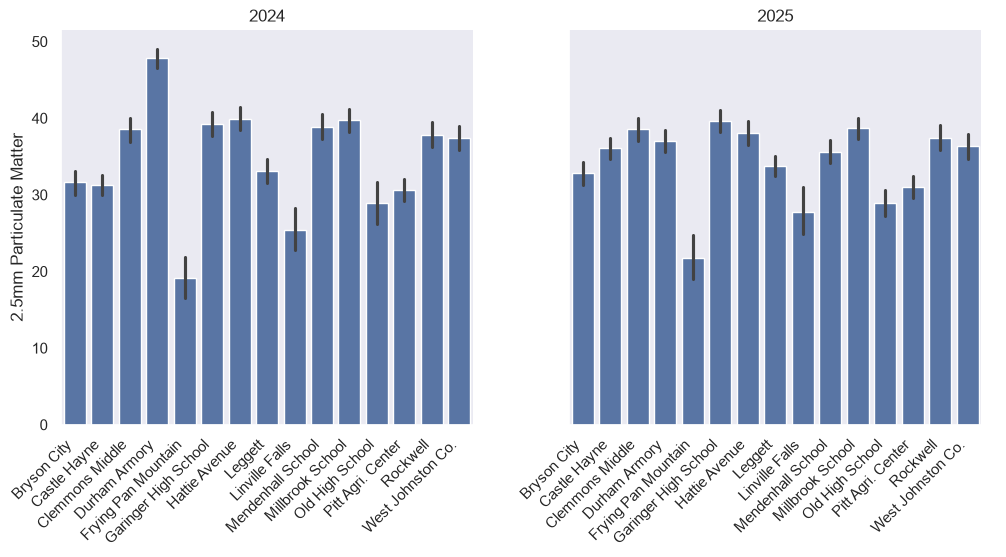

In [42]:
#Create a bar plot of mean PM2.5 (with error bars) with a facet for each year
g = sns.catplot(
    data=EPAair,
    x="Local Site Name",
    y="PM2.5",
    kind="bar",
    col="Year",
    col_wrap=2 #If needed, to set limit on number of plots per row
)

#Set y-axis label and remove x-axis label
g.set(
    xlabel='',
    ylabel = '2.5mm Particulate Matter'
)

#Set x-ticklabels
g.set_xticklabels(rotation=45, horizontalalignment='right')

#Set titles using the facet column value
g.set_titles('{col_name}');

#### 👉 You try it:
* Change the above plot so that creates a **box** plot of `PM2.5` values for each `Month_name`, with a facet for each `Local Site Name`

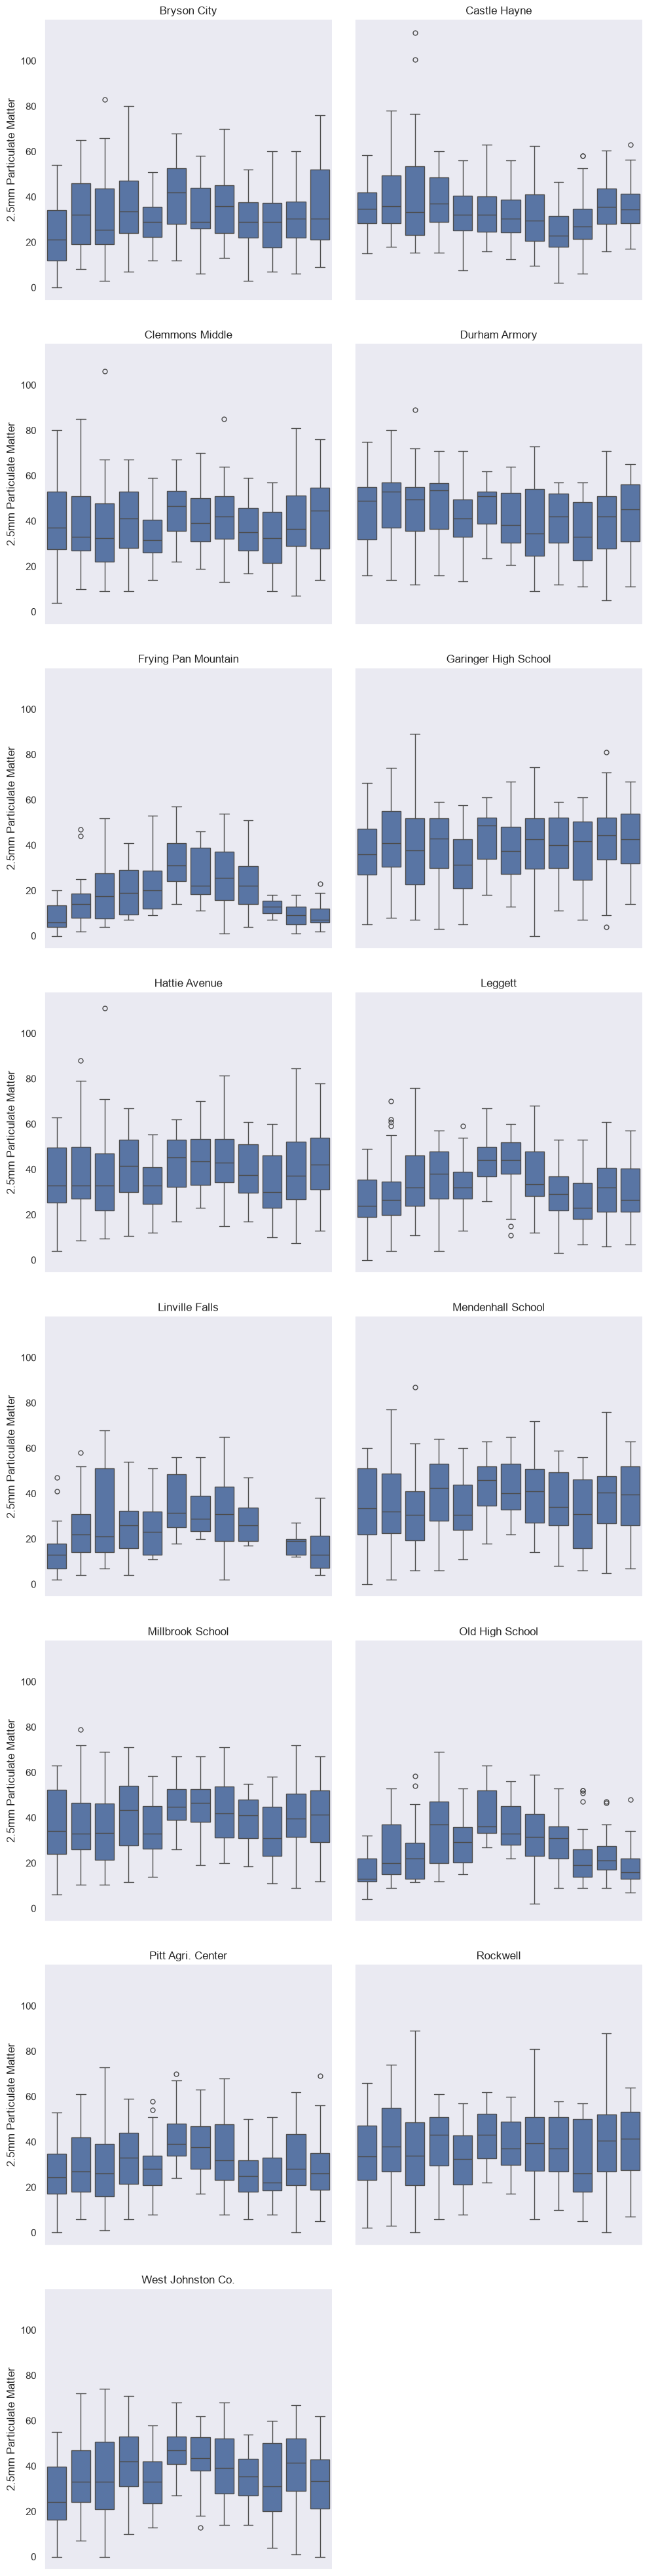

In [43]:
#Create a box plot of mean PM2.5 (with error bars) by month with a facet for each site
g = sns.catplot(
    data=EPAair,
    x="Month_name",
    y="PM2.5",
    kind="box",
    col="Local Site Name",
    col_wrap=2 #If needed, to set limit on number of plots per row
)

#Set y-axis label and remove x-axis label
g.set(
    xlabel='',
    ylabel = '2.5mm Particulate Matter'
)

#Set x-ticklabels
g.set_xticklabels(rotation=45, horizontalalignment='right')

#Set titles using the facet column value
g.set_titles('{col_name}');

---
## 📊Reference Lines and Annotations
* Well-designed figures often include more than just data points. Reference lines and annotations help draw attention to important values, thresholds, trends, or notable observations.


### Reference Lines
* The `FacetGrid.refline()` method adds horizontal or vertical reference lines to every panel of a figure.

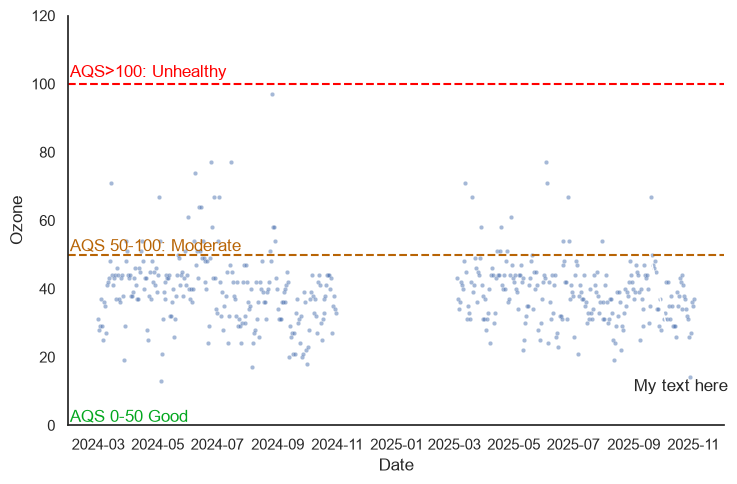

In [44]:
#reset the theme
sns.set_theme(style='white')

# Create the FacetGrid
g = sns.relplot(
    data=EPAair.loc[EPAair['Local Site Name'] == 'Durham Armory'],
    x='Date',
    y='Ozone',
    alpha=0.5,
    marker='o',
    s=10,
    aspect=1.5
)

# Customize the plot
g.set(ylim=(0, 120))

# Add reference lines
g.refline(y=50, color='#B86405', linestyle='--')
g.refline(y=100, color='red', linestyle='--')

# Add some text, using coordinats to place it
g.ax.text(
    x=pd.Timestamp(2024, 2, 1),
    y=102,
    s='AQS>100: Unhealthy',
    color='red')

g.ax.text(
    x=pd.Timestamp(2024, 2, 1),
    y=51,
    s='AQS 50-100: Moderate',
    color="#B86405"
)

g.ax.text(
    x=pd.Timestamp(2024, 2, 1),
    y=1,
    s='AQS 0-50 Good',
    color="#02A71E",
)

g.ax.annotate(
    "My text here",
    xy=(pd.Timestamp(2025,9,1),70),      # ← point the arrow POINTS TO
    xytext=(pd.Timestamp(2025,9,1), 10),  # ← location of the TEXT
    arrowprops={"arrowstyle": "->"}
);

---
## 📊 Saving your plot

Once you have created a figure, you can save it for use in reports, presentations, or publications. With Seaborn figure-level plots, use the `savefig()` method on the figure object before displaying the plot. If you are saving a figure for submission or publication, save it before making additional changes or creating another figure.

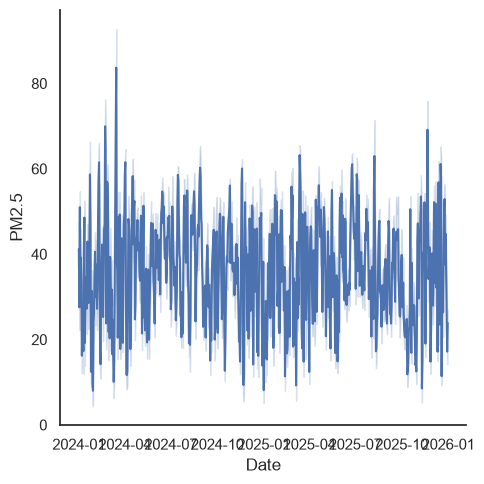

In [45]:
g = sns.relplot(
    data=EPAair,
    x="Date",
    y="PM2.5",
    kind="line"
)

g.savefig("pm25_timeseries.png", dpi=300, bbox_inches="tight")

Common file formats include:

* PNG – Best for presentations and web pages.
* PDF – Vector format, ideal for reports and publications.
* SVG – Vector format for web graphics and editing in illustration software.

A resolution of 300 dpi is generally recommended for printed documents, while the default resolution is usually sufficient for on-screen viewing.

---
## Summary
As you continue working with Seaborn, it helps to remember that different types of customization are handled by different methods. Rather than trying to memorize every function, think about what you want to change—the overall theme, plot labels, legend, facet titles, or annotations—and then use the appropriate method. The table below summarizes the most common customization tasks covered in this lesson and the Seaborn function used to accomplish each one.

| Want to change...      | Use...                                        |
| ---------------------- | --------------------------------------------- |
| Overall look           | `sns.set_theme()`                             |
| Theme details          | `rc={...}`                                    |
| Titles, labels, limits | `g.set()`                                     |
| Tick labels            | `g.set_xticklabels()` / `g.set_yticklabels()` |
| Facet titles           | `g.set_titles()`                              |
| Legend                 | `sns.move_legend()`                           |
| Reference lines        | `g.refline()`                                 |
| Save figure            | `g.savefig()`                                 |
